### Section 1: Environment Setup

In [5]:
import pandas as pd
import numpy as np
import talib
import pynance as pn
import matplotlib.pyplot as plt
import seaborn as sns

#### 1.2 Data Loading
Loading the historical stock price data for GOOG from the yfinance directory.

In [8]:
# Using the specific path from your project structure
df_goog = pd.read_csv('../data/raw/yfinance_data/Data/GOOG.csv')
df_goog.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,7.948608,7.960977,7.557264,7.633949,144961322
1,2009-01-05,8.115089,8.194003,7.792268,7.940692,196293007
2,2009-01-06,8.263762,8.430492,8.074027,8.237046,257971329
3,2009-01-07,7.965677,8.185839,7.885034,8.121770,180453860
4,2009-01-08,8.044340,8.044340,7.850152,7.873406,144567852


#### 1.3 Date Formatting
Converting the date column to datetime objects and setting it as the index for time-series compatibility.

In [9]:
df_goog['Date'] = pd.to_datetime(df_goog['Date'])
df_goog.set_index('Date', inplace=True)

#### 1.4 Type Casting & Quality Check
Ensuring Open, High, Low, Close, and Volume (OHLCV) are numeric and checking for null values.

In [10]:
cols = ['Open', 'High', 'Low', 'Close', 'Volume']
df_goog[cols] = df_goog[cols].apply(pd.to_numeric, errors='coerce')

# Handling missing values via forward fill
print("Missing values before cleaning:\n", df_goog.isnull().sum())
df_goog.fillna(method='ffill', inplace=True)

Missing values before cleaning:
 Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


C:\Users\HP\AppData\Local\Temp\ipykernel_20656\250426881.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_goog.fillna(method='ffill', inplace=True)


### Section 2: Technical Indicators
#### 2.1 Moving Averages (SMA & EMA)
Calculating the 20-day Simple Moving Average and Exponential Moving Average.

In [12]:
df_goog['SMA_20'] = talib.SMA(df_goog['Close'], timeperiod=20)
df_goog['EMA_20'] = talib.EMA(df_goog['Close'], timeperiod=20)

#### 2.2 Relative Strength Index (RSI)
Identifying overbought (>70) and oversold (<30) conditions.

In [13]:
df_goog['RSI'] = talib.RSI(df_goog['Close'], timeperiod=14)

#### 2.3 MACD (Moving Average Convergence Divergence)
Detecting momentum shifts using the MACD line, signal line, and histogram.

In [16]:
df_goog['macd'], df_goog['macd_signal'], df_goog['macd_hist'] = talib.MACD(
    df_goog['Close'], 
    fastperiod=12, 
    slowperiod=26, 
    signalperiod=9
)

### Section 3: Advanced Financial Metrics
Using PyNance to compute additional metrics such as stock returns.

In [ ]:
# Calculate Daily Returns using the Close price
df_goog['Returns'] = df_goog['Close'].pct_change()

df_goog[['Close', 'Returns']].head()

,Close,Returns
Date,,
2009-01-02,7.948608,NaN
2009-01-05,8.115089,0.020945
2009-01-06,8.263762,0.018321
2009-01-07,7.965677,-0.036071
2009-01-08,8.044340,0.009875


### Section 4: Data Visualization
#### 4.1 Price Action and Moving Averages
Overlaying SMA and EMA on the Closing Price.

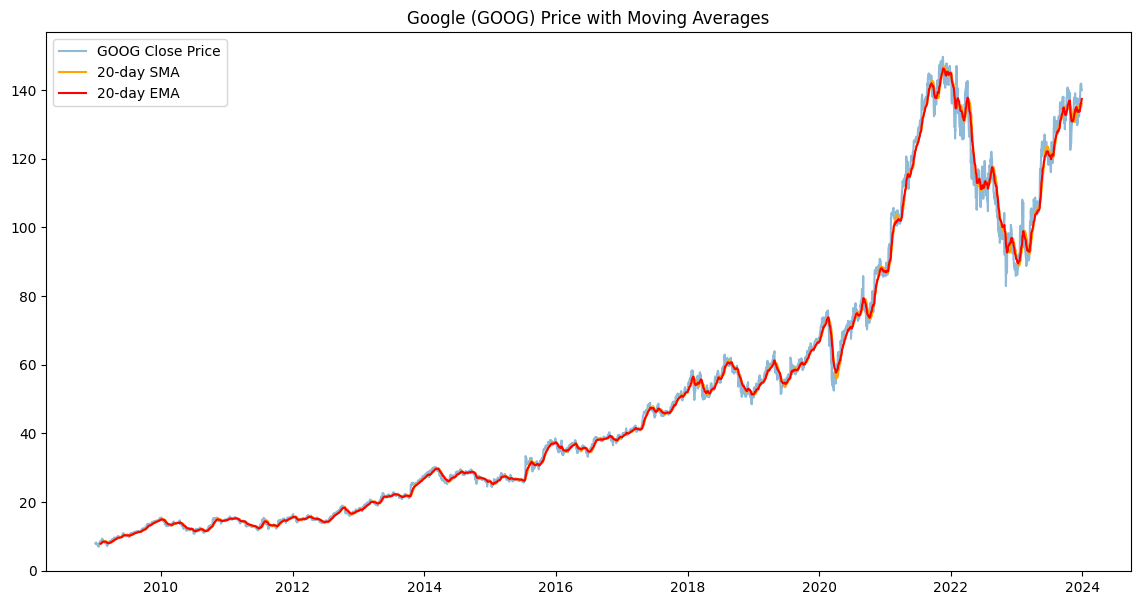

In [21]:
plt.figure(figsize=(14, 7))
plt.plot(df_goog['Close'], label='GOOG Close Price', alpha=0.5)
plt.plot(df_goog['SMA_20'], label='20-day SMA', color='orange')
plt.plot(df_goog['EMA_20'], label='20-day EMA', color='red')
plt.title('Google (GOOG) Price with Moving Averages')
plt.legend()
plt.show()

#### 4.2 RSI & MACD Momentum Panels
Visualizing overbought/oversold conditions and trend reversals.

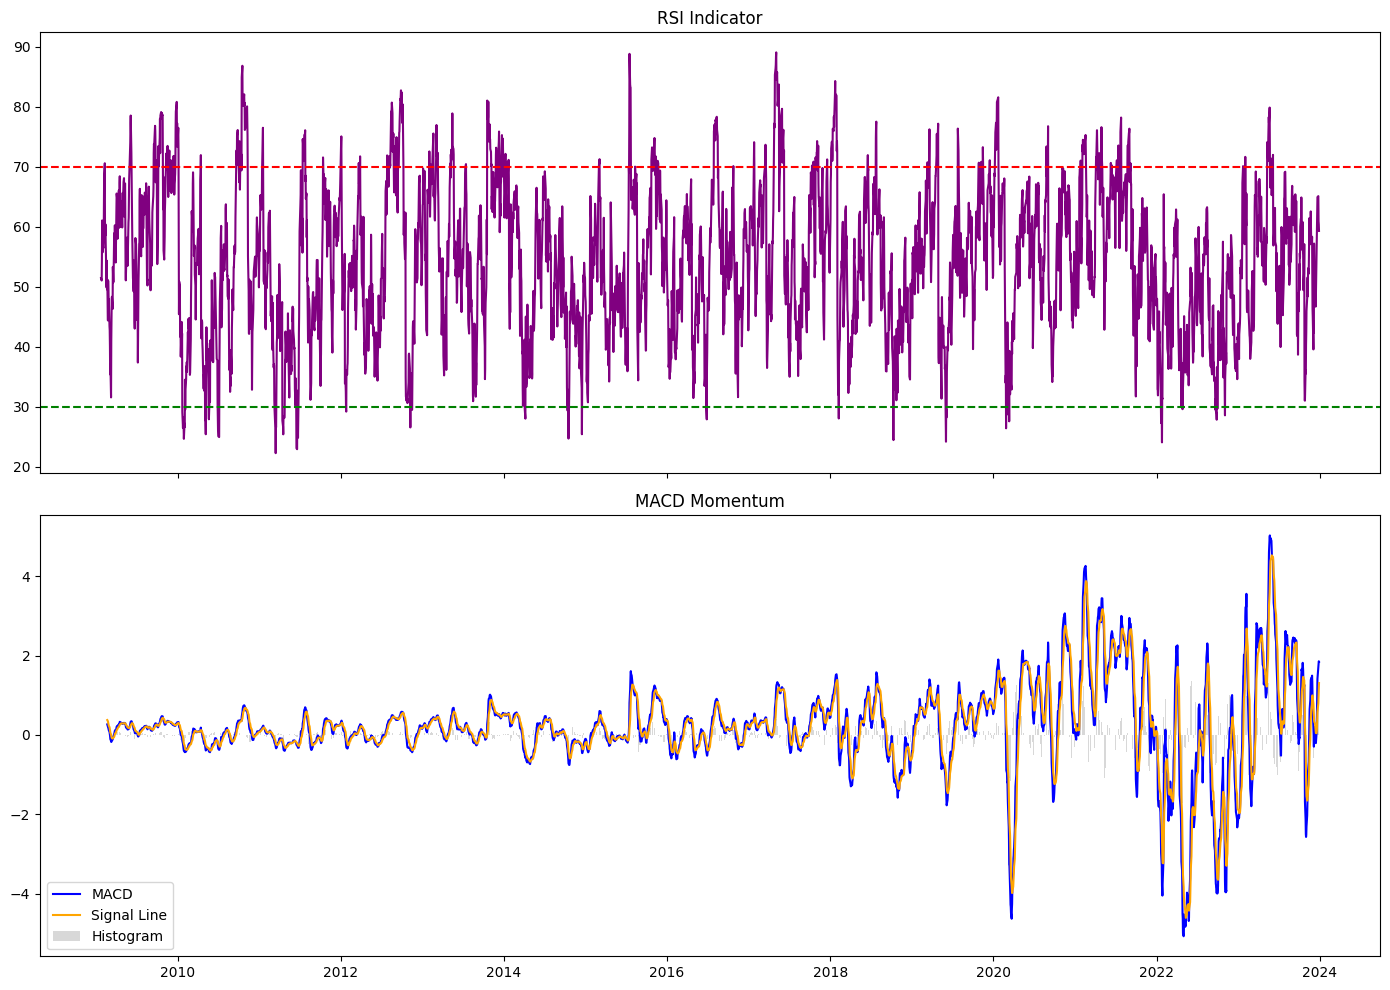

In [22]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# RSI Plot
ax1.plot(df_goog['RSI'], color='purple')
ax1.axhline(70, color='red', linestyle='--')
ax1.axhline(30, color='green', linestyle='--')
ax1.set_title('RSI Indicator')

# MACD Plot
ax2.plot(df_goog['macd'], label='MACD', color='blue')
ax2.plot(df_goog['macd_signal'], label='Signal Line', color='orange')
ax2.bar(df_goog.index, df_goog['macd_hist'], label='Histogram', color='gray', alpha=0.3)
ax2.set_title('MACD Momentum')
ax2.legend()

plt.tight_layout()
plt.show()